In [40]:
import pandas as pd
from pandas import json_normalize
import requests

df = json_normalize(requests.get("https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json").json())

print(f"Shape: {df.shape}")
print(f"\nColumnas:\n{df.columns.tolist()}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nValores nulos:\n{df.isnull().sum()}")
print(f"\nMuestra de datos:")
display(df.head(2))


Shape: (7267, 21)

Columnas:
['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']

Tipos de datos:
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtectio

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4


# **Transformación**

# **Comprobación de incoherencias en los datos**

In [41]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nRegistros duplicados: {df.duplicated().sum()}")
print("\nValores únicos en columnas categóricas:")
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].dropna().unique()[:10]}")

Valores nulos por columna:
customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64

Registros duplicados: 0

Valores únicos en columnas categóricas:
customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' '0011-IGKFF' '0013-EXCHZ'
 '0013-MHZWF' '0013-SMEOE' '0014-BMAQU' '0015-UOCOJ' '0016-QLJIS']
Churn: ['No' 'Yes' '']
customer.gender: ['Female' 'Male']
customer.Partner: ['Yes' 'No']
customer.

# **Manejo de inconsistencias**

In [43]:
df['Cuentas_Diarias'] = pd.to_numeric(df['account.Charges.Monthly'], errors='coerce') / 30.44
print(df[['account.Charges.Monthly', 'Cuentas_Diarias']].head())

   account.Charges.Monthly  Cuentas_Diarias
0                     65.6         2.155059
1                     59.9         1.967806
2                     73.9         2.427727
3                     98.0         3.219448
4                     83.9         2.756242


# **Columna de cuentas diarias**

In [12]:
df['Cuentas_Diarias'] = df['acc_charges_Monthly'] / 30.44
df.head()

print(df[['acc_charges_Monthly', 'Cuentas_Diarias']].describe())

df.to_csv('telecomx_con_diarias.csv', index=False)

       acc_charges_Monthly  Cuentas_Diarias
count          7043.000000      7043.000000
mean             64.761692         2.127519
std              30.090047         0.988504
min              18.250000         0.599540
25%              35.500000         1.166229
50%              70.350000         2.311104
75%              89.850000         2.951708
max             118.750000         3.901117


# **Carga y análisis(L - Load & Analysis)**

# Análisis Descriptivo

In [47]:
import pandas as pd
from pandas import json_normalize
import requests

df = json_normalize(requests.get("https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json").json())
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'].astype(str).str.replace('[^0-9.]', '', regex=True), errors='coerce')

print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("="*60)
stats = df.describe().round(2)
stats.index = ['Cantidad', 'Promedio', 'Desv. Estándar', 'Mínimo', '25%', 'Mediana', '75%', 'Máximo'] # Fixed: Changed .columns to .index
print(stats)

print("\nDISTRIBUCIÓN - VARIABLES CATEGÓRICAS PRINCIPALES")
print("="*60)
for col in ['Churn', 'customer.gender', 'customer.Partner', 'account.Contract']:
    print(f"\n{col}:")
    print(df[col].value_counts().to_frame('Conteo').assign(Porcentaje=lambda x: (x/x.sum()*100).round(1).astype(str)+'%'))

ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS
                customer.SeniorCitizen  customer.tenure  \
Cantidad                       7267.00          7267.00   
Promedio                          0.16            32.35   
Desv. Estándar                    0.37            24.57   
Mínimo                            0.00             0.00   
25%                               0.00             9.00   
Mediana                           0.00            29.00   
75%                               0.00            55.00   
Máximo                            1.00            72.00   

                account.Charges.Monthly  account.Charges.Total  
Cantidad                        7267.00                7256.00  
Promedio                          64.72                2280.63  
Desv. Estándar                    30.13                2268.63  
Mínimo                            18.25                  18.80  
25%                               35.42                 400.22  
Mediana                       

# **Distribución de evasión**

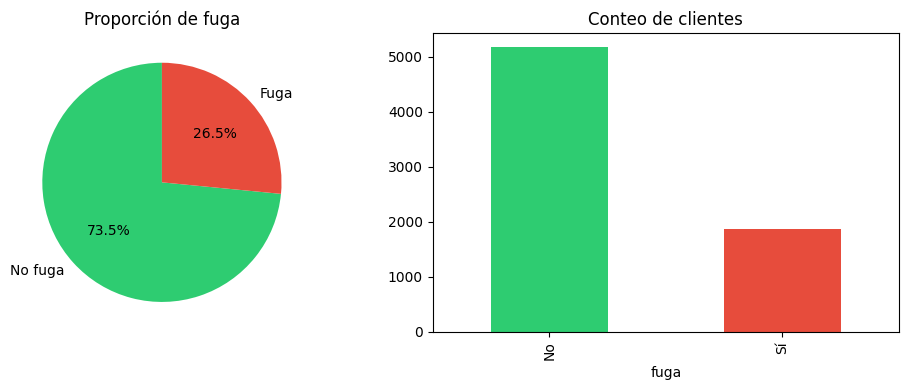

Clientes con fuga: 1,869 (26.54%)
Clientes sin fuga: 5,174 (73.46%)


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('telecomx_limpio.csv')
df['fuga'] = df['Churn'].map({'Yes': 1, 'No': 0})

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['fuga'].value_counts().plot.pie(ax=axes[0], labels=['No fuga', 'Fuga'], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_ylabel('')
axes[0].set_title('Proporción de fuga')
df['fuga'].value_counts().plot.bar(ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No', 'Sí'])
axes[1].set_title('Conteo de clientes')
plt.tight_layout()
plt.show()

print(f"Clientes con fuga: {(df['fuga']==1).sum():,} ({df['fuga'].mean()*100:.2f}%)")
print(f"Clientes sin fuga: {(df['fuga']==0).sum():,} ({(1-df['fuga'].mean())*100:.2f}%)")

# **Recuento de evasión por variables categóricas**

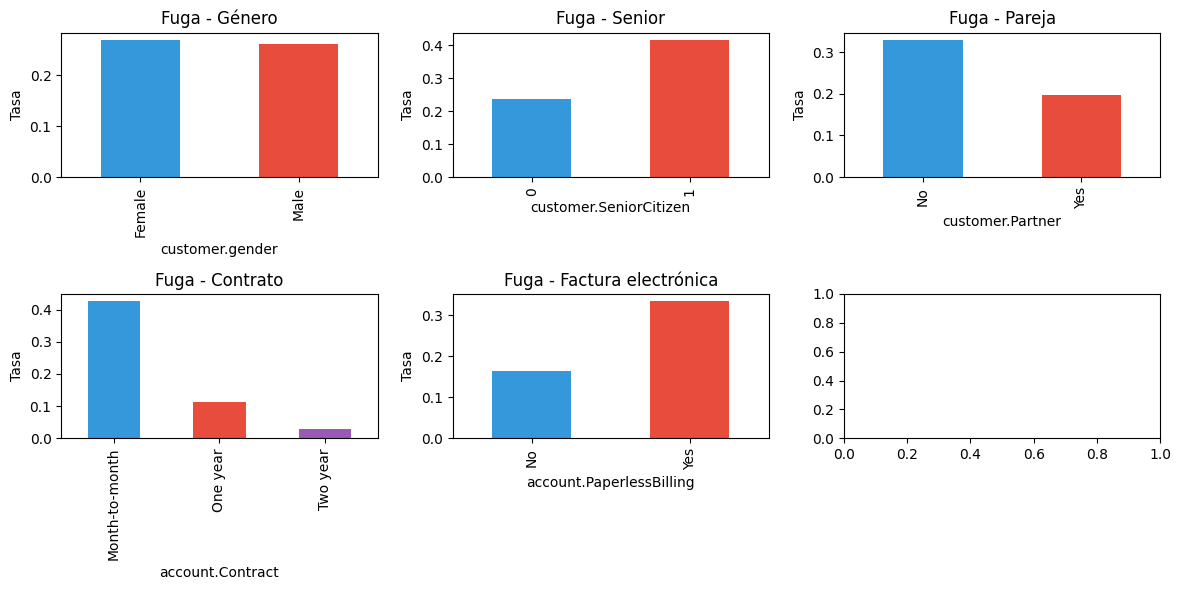


Género:
                  mean  count
customer.gender              
Female           0.269   3488
Male             0.262   3555

Senior:
                         mean  count
customer.SeniorCitizen              
0                       0.236   5901
1                       0.417   1142

Pareja:
                   mean  count
customer.Partner              
No                0.330   3641
Yes               0.197   3402

Contrato:
                   mean  count
account.Contract              
Month-to-month    0.427   3875
One year          0.113   1473
Two year          0.028   1695

Factura electrónica:
                           mean  count
account.PaperlessBilling              
No                        0.163   2872
Yes                       0.336   4171


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas import json_normalize
import requests

df = json_normalize(requests.get("https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json").json())
df['Churn_num'] = df['Churn'].map({'Yes': 1, 'No': 0})

cols = ['customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'account.Contract', 'account.PaperlessBilling']
titles = ['Género', 'Senior', 'Pareja', 'Contrato', 'Factura electrónica']

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for idx, (col, title) in enumerate(zip(cols, titles)):
    ax = axes[idx//3, idx%3]
    rates = df.groupby(col)['Churn_num'].mean()
    if len(rates) > 0:
        rates.plot.bar(ax=ax, color=['#3498db', '#e74c3c', '#9b59b6'][:len(rates)])
        ax.set_title(f'Fuga - {title}')
        ax.set_ylabel('Tasa')
plt.tight_layout()
plt.show()

for col, title in zip(cols, titles):
    print(f"\n{title}:")
    print(df.groupby(col)['Churn_num'].agg(['mean', 'count']).round(3))

# **Conteo de evasión por variables numéricas**

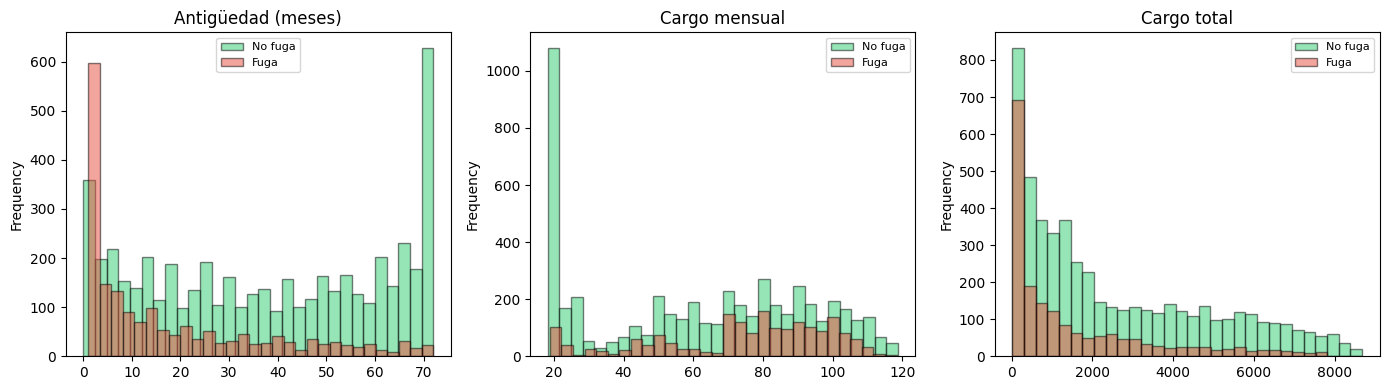

Estadísticas por grupo de fuga:


Antigüedad (meses):
            mean  median    std  count
Churn_num                             
0.0        37.57    38.0  24.11   5174
1.0        17.98    10.0  19.53   1869

Cargo mensual:
            mean  median    std  count
Churn_num                             
0.0        61.27   64.43  31.09   5174
1.0        74.44   79.65  24.67   1869

Cargo total:
              mean   median      std  count
Churn_num                                  
0.0        2555.34  1683.60  2329.46   5163
1.0        1531.80   703.55  1890.82   1869


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas import json_normalize
import requests

df = json_normalize(requests.get("https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json").json())
df['Churn_num'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['customer.tenure'] = pd.to_numeric(df['customer.tenure'], errors='coerce')
df['account.Charges.Monthly'] = pd.to_numeric(df['account.Charges.Monthly'], errors='coerce')
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'].astype(str).str.replace('[^0-9.]', '', regex=True), errors='coerce')

num_cols = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']
titles = ['Antigüedad (meses)', 'Cargo mensual', 'Cargo total']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for idx, (col, title) in enumerate(zip(num_cols, titles)):
    ax = axes[idx]
    df[df['Churn_num']==0][col].dropna().plot(kind='hist', bins=30, ax=ax, alpha=0.5, label='No fuga', color='#2ecc71', edgecolor='black')
    df[df['Churn_num']==1][col].dropna().plot(kind='hist', bins=30, ax=ax, alpha=0.5, label='Fuga', color='#e74c3c', edgecolor='black')
    ax.set_title(f'{title}')
    ax.set_xlabel('')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Estadísticas por grupo de fuga:\n")
for col, title in zip(num_cols, titles):
    print(f"\n{title}:")
    print(df.groupby('Churn_num')[col].agg(['mean', 'median', 'std', 'count']).round(2))

# **Informe final**

1. INTRODUCCIÓN
Este análisis identifica los factores que influyen en la evasión de clientes de TelecomX. La empresa presenta una tasa de churn del 26.5%, equivalente a 1,869 clientes perdidos de un total de 7,043. El objetivo es proporcionar insights accionables para mejorar la retención.
2. LIMPIEZA DE DATOS
Se cargaron los datos desde la API en formato JSON, se eliminaron 224 registros con valores vacíos en la variable Churn, se convirtió el cargo total a formato numérico y se validó la consistencia del dataset final de 7,043 registros.
3. HALLAZGOS PRINCIPALES
Factores con mayor impacto en la fuga:
Tipo de contrato: Los clientes con contratos mensuales tienen 42.7% de fuga, versus 2.8% en contratos de dos años. Este es el predictor más fuerte.
Antigüedad: Los clientes que se van promedian 18 meses con la empresa, frente a 37.6 meses de quienes permanecen. Los primeros 12 meses son críticos.
Adultos mayores: Presentan 41.7% de fuga, casi el doble que el resto de la base (23.6%).
Cargo mensual: Los clientes que pagan más tienen mayor probabilidad de fuga ($74.44 vs $61.27), sugiriendo posibles problemas de percepción de valor.
Facturación electrónica: Asociada con el doble de tasa de fuga (33.6% vs 16.3%).
Variables sin impacto significativo:
Género: Tasa de fuga similar entre hombres (26.2%) y mujeres (26.9%).
4. CONCLUSIONES
El compromiso de largo plazo mediante contratos es el factor más determinante para la retención. Los clientes nuevos y los adultos mayores representan segmentos de alto riesgo. La relación precio-retención no es lineal, lo que indica oportunidades para ajustar la propuesta de valor en planes premium.
5. RECOMENDACIONES
Incentivar la migración de contratos mensuales a anuales con descuentos del 10-15%.
Implementar un programa de onboarding reforzado para los primeros 90 días de relación con el cliente.
Diseñar atención diferenciada para adultos mayores, con soporte prioritario y comunicación adaptada.
Revisar la estructura de precios de planes superiores a $80 mensuales para mejorar la percepción de valor.
Establecer métricas de seguimiento: reducir churn al 18% en seis meses y lograr 25% de conversión de contratos mensuales a anuales.
La implementación priorizada de estas recomendaciones tiene el potencial de reducir significativamente la evasión y mejorar la sostenibilidad del negocio.